In [17]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

feature_matrix = pd.read_csv("feature_matrix.csv")
tag_matrix = pd.read_csv('tag_matrix.csv')
phone_names = pd.read_csv("preprocess_1_new.csv")

#### Kiểm tra kích thước dữ liệu

In [18]:
import numpy as np
import pandas as pd


def validate_feature_matrix_integrity(df, expected_shape=(445, 32)):
    """Hàm tự động kiểm định tính toàn vẹn và cấu trúc của ma trận đặc trưng (feature_matrix).

    df: DataFrame cần kiểm tra (feature_matrix) expected_shape: Kích thước kỳ vọng
    (dòng, cột)
    """
    print("=" * 65)
    print("   BÁO CÁO KIỂM ĐỊNH TÍNH TOÀN VẸN DỮ LIỆU (DATA INTEGRITY)   ")
    print("=" * 65)

    # -----------------------------------------------------------------
    # Bước 1 — Kiểm tra kích thước và kiểu dữ liệu
    # -----------------------------------------------------------------
    print("\n🔹 BƯỚC 1: KIỂM TRA KÍCH THƯỚC VÀ KIỂU DỮ LIỆU")
    actual_shape = df.shape
    shape_passed = actual_shape == expected_shape

    # Kiểm tra Shape
    if shape_passed:
        print(
            f"  ✅ Kích thước ma trận chính xác: {actual_shape[0]} dòng × {actual_shape[1]} cột."
        )
    else:
        print(
            f"  ❌ LỖI SỐ CHIỀU DỮ LIỆU! Kỳ vọng {expected_shape}, thực tế pipeline xuất ra {actual_shape}."
        )

    # Kiểm tra kiểu dữ liệu float64 cho toàn bộ các cột
    not_float64_cols = df.select_dtypes(exclude=[np.float64]).columns.tolist()
    if len(not_float64_cols) == 0:
        print(
            "  ✅ Đồng nhất kiểu dữ liệu: 100% các cột đều đạt chuẩn 'float64'."
        )
    else:
        print(
            f"  ❌ LỖI KIỂU DỮ LIỆU! Có {len(not_float64_cols)} cột không phải float64: {not_float64_cols}"
        )

    # -----------------------------------------------------------------
    # Bước 2 — Kiểm tra 100% Non-null
    # -----------------------------------------------------------------
    print("\n🔹 BƯỚC 2: KIỂM TRA GIÁ TRỊ KHUYẾT THIẾU (NON-NULL)")
    total_nulls = df.isnull().sum().sum()

    if total_nulls == 0:
        print(
            "  ✅ Đạt tiêu chuẩn Non-null: Ma trận sạch 100%, không chứa bất kỳ giá trị Null nào."
        )
        print(
            "     -> Đủ điều kiện toán học nghiêm ngặt để chạy thuật toán Cosine Similarity."
        )
    else:
        print(
            f"  ❌ CẢNH BÁO NGHIÊM TRỌNG! Phát hiện {total_nulls} giá trị trống (Null) trong ma trận."
        )
        # Hiển thị chi tiết các cột bị dính lỗi Null
        null_series = df.isnull().sum()
        print("     Chi tiết các cột chứa Null:")
        print(null_series[null_series > 0])

    # -----------------------------------------------------------------
    # Bước 3 — Kiểm tra thang đo hình học [0, 1]
    # -----------------------------------------------------------------
    print("\n🔹 BƯỚC 3: KIỂM TRA THANG ĐO CHUẨN [0, 1]")
    column_mins = df.min()
    column_maxs = df.max()

    # Tìm các cột vi phạm biên
    out_of_bound_min = column_mins[column_mins < 0.0]
    out_of_bound_max = column_maxs[column_maxs > 1.0]

    if len(out_of_bound_min) == 0 and len(out_of_bound_max) == 0:
        print(
            f"  ✅ ĐẠT CHUẨN HÌNH HỌC! Toàn bộ giá trị nằm nghiêm chỉnh trong khoảng [0.0, 1.0]."
        )
        print(
            f"     (Min thấp nhất toàn cục: {column_mins.min():.4f} | Max cao nhất toàn cục: {column_maxs.max():.4f})"
        )
    else:
        if len(out_of_bound_min) > 0:
            print(
                "  ❌ LỖI PIPELINE! Phát hiện các cột có giá trị BỊ LỌT XUỐNG ÂM (< 0):"
            )
            for col, val in out_of_bound_min.items():
                print(f"     -> Cột '{col}': giá trị Min = {val}")
        if len(out_of_bound_max) > 0:
            print(
                "  ❌ LỖI PIPELINE! Phát hiện các cột có giá trị BỊ VỌT QUÁ TRẦN (> 1):"
            )
            for col, val in out_of_bound_max.items():
                print(f"     -> Cột '{col}': giá trị Max = {val}")

    # -----------------------------------------------------------------
    # KẾT LUẬN CHUNG
    # -----------------------------------------------------------------
    print("\n" + "=" * 65)
    all_passed = (
        shape_passed
        and (len(not_float64_cols) == 0)
        and (total_nulls == 0)
        and (len(out_of_bound_min) == 0)
        and (len(out_of_bound_max) == 0)
    )

    if all_passed:
        print(
            " 🎉 KẾT LUẬN: MA TRẬN ĐẠT TOÀN VẸN CHUẨN HÌNH HỌC - SẴN SÀNG KHUYẾN NGHỊ!"
        )
    else:
        print(
            " 🚨 KẾT LUẬN: PHÁT HIỆN LỖI TOÀN VẸN, CẦN RÀ SOÁT LẠI CODE TIỀN XỬ LÝ!"
        )
    print("=" * 65)


# =====================================================================
# HƯỚNG DẪN SỬ DỤNG TRÊN NOTEBOOK CỦA BẠN:
# =====================================================================
# Sau khi bạn đã tạo xong biến 'feature_matrix' ở cuối bước Preprocess,
# bạn chỉ cần gọi dòng lệnh này để kích hoạt bộ kiểm định tự động:

validate_feature_matrix_integrity(feature_matrix)

   BÁO CÁO KIỂM ĐỊNH TÍNH TOÀN VẸN DỮ LIỆU (DATA INTEGRITY)   

🔹 BƯỚC 1: KIỂM TRA KÍCH THƯỚC VÀ KIỂU DỮ LIỆU
  ❌ LỖI SỐ CHIỀU DỮ LIỆU! Kỳ vọng (445, 32), thực tế pipeline xuất ra (445, 40).
  ✅ Đồng nhất kiểu dữ liệu: 100% các cột đều đạt chuẩn 'float64'.

🔹 BƯỚC 2: KIỂM TRA GIÁ TRỊ KHUYẾT THIẾU (NON-NULL)
  ✅ Đạt tiêu chuẩn Non-null: Ma trận sạch 100%, không chứa bất kỳ giá trị Null nào.
     -> Đủ điều kiện toán học nghiêm ngặt để chạy thuật toán Cosine Similarity.

🔹 BƯỚC 3: KIỂM TRA THANG ĐO CHUẨN [0, 1]
  ❌ LỖI PIPELINE! Phát hiện các cột có giá trị BỊ VỌT QUÁ TRẦN (> 1):
     -> Cột 'rear_mp_max': giá trị Max = 1.0000000000000002

 🚨 KẾT LUẬN: PHÁT HIỆN LỖI TOÀN VẸN, CẦN RÀ SOÁT LẠI CODE TIỀN XỬ LÝ!


   BÁO CÁO ĐÁNH GIÁ PHÂN PHỐI THANG ĐO, PHƯƠNG SAI VÀ ĐỘ CÂN BẰNG OHE   

🔹 BƯỚC 4: TRỰC QUAN HÓA PHÂN PHỐI 10 BIẾN SỐ LIÊN TỤC
  -> Đang khởi tạo lưới đồ thị Histogram... Vui lòng kiểm tra biểu đồ hiển thị.


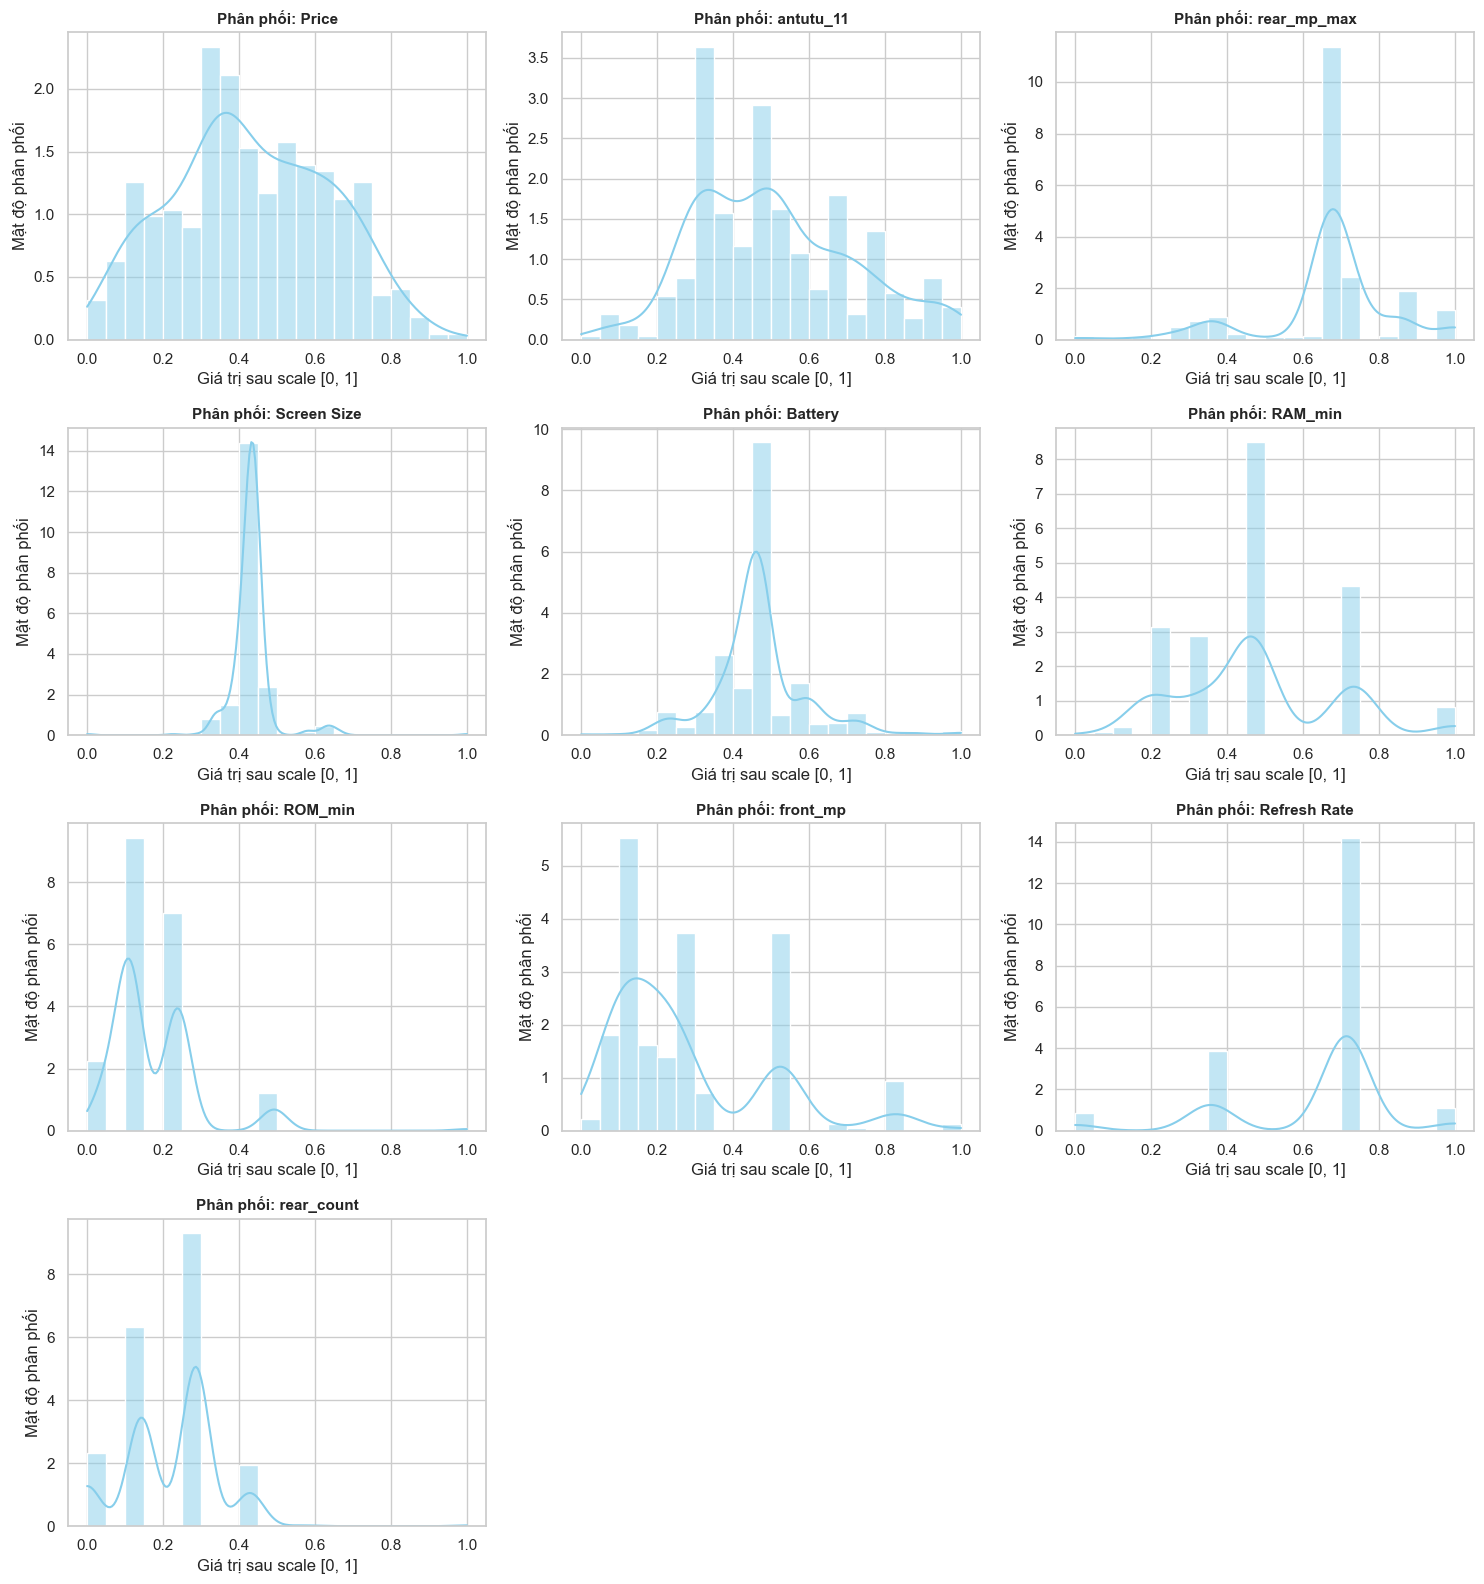


🔹 BƯỚC 5: KIỂM TRA PHƯƠNG SAI (VARIANCE CHẨN ĐOÁN)
  ⚠️ CẢNH BÁO PHƯƠNG SAI THẤP (< 0.01): Có 1 cột gần như đi ngang (Lười biến động):
     -> Cột 'Screen Size' (Thông số liên tục): Variance = 0.00345

🔹 BƯỚC 6: KIỂM TRA ĐỘ MẤT CÂN BẰNG CỰC ĐOAN TRÊN CÁC CỘT OHE
  ✅ ĐẠT TIÊU CHUẨN: Không phát hiện nhãn OHE hiếm. Các nhãn phân loại đều có mật độ bao phủ tốt (> 2%).



In [19]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns


def evaluate_distributions_and_variance(df):
    """Hàm hiện thực hóa Bước 4, 5, 6: Đánh giá phân phối sau scale, kiểm tra

    phương sai thấp và độ mất cân bằng cực đoan của các cột OHE.
    """
    print("=" * 75)
    print("   BÁO CÁO ĐÁNH GIÁ PHÂN PHỐI THANG ĐO, PHƯƠNG SAI VÀ ĐỘ CÂN BẰNG OHE   ")
    print("=" * 75)

    # Tự động phân loại: Biến nhị phân (OHE) chỉ chứa tập con của {0.0, 1.0}
    binary_cols = [
        c for c in df.columns if set(df[c].unique()).issubset({0.0, 1.0})
    ]
    num_cols = [c for c in df.columns if c not in binary_cols]

    # -----------------------------------------------------------------
    # Bước 4 — Phân phối từng cột số sau scaling (Histogram)
    # -----------------------------------------------------------------
    print(
        f"\n🔹 BƯỚC 4: TRỰC QUAN HÓA PHÂN PHỐI {len(num_cols)} BIẾN SỐ LIÊN TỤC"
    )
    print(
        "  -> Đang khởi tạo lưới đồ thị Histogram... Vui lòng kiểm tra biểu đồ hiển thị."
    )

    # Tính toán kích thước lưới đồ thị (3 cột)
    n_num = len(num_cols)
    cols_grid = 3
    rows_grid = int(np.ceil(n_num / cols_grid))

    plt.figure(figsize=(5 * cols_grid, 4 * rows_grid))
    sns.set_theme(style="whitegrid")

    for i, col in enumerate(num_cols):
        plt.subplot(rows_grid, cols_grid, i + 1)
        # Vẽ histogram kèm đường cong mật độ KDE
        sns.histplot(df[col], kde=True, color="skyblue", bins=20, stat="density")

        plt.title(f"Phân phối: {col}", fontsize=11, fontweight="bold")
        plt.xlabel("Giá trị sau scale [0, 1]")
        plt.ylabel("Mật độ phân phối")
        plt.xlim(-0.05, 1.05)

        # Kiểm tra thuật toán: Đo lường xem dữ liệu có bị dồn 100% về sát 0 hoặc 1 không
        near_zero_ratio = (df[col] < 0.05).sum() / len(df)
        near_one_ratio = (df[col] > 0.95).sum() / len(df)

        if near_zero_ratio > 0.70:
            print(
                f"  ⚠️ CẢNH BÁO BẸP PHÂN PHỐI: Cột '{col}' có tới {near_zero_ratio*100:.1f}% dữ liệu bị dồn sát mốc 0!"
            )
        elif near_one_ratio > 0.70:
            print(
                f"  ⚠️ CẢNH BÁO BẸP PHÂN PHỐI: Cột '{col}' có tới {near_one_ratio*100:.1f}% dữ liệu bị dồn sát mốc 1!"
            )

    plt.tight_layout()
    plt.show()
   
    # -----------------------------------------------------------------
    # Bước 5 — Kiểm tra phương sai (Variance)
    # -----------------------------------------------------------------
    print("\n🔹 BƯỚC 5: KIỂM TRA PHƯƠNG SAI (VARIANCE CHẨN ĐOÁN)")
    variances = df.var()
    low_variance_cols = variances[variances < 0.01]

    if len(low_variance_cols) == 0:
        print(
            "  ✅ ĐẠT TIÊU CHUẨN: 100% các cột đều có phương sai lớn hơn 0.01. Các đặc trưng giàu tính phân biệt!"
        )
    else:
        print(
            f"  ⚠️ CẢNH BÁO PHƯƠNG SAI THẤP (< 0.01): Có {len(low_variance_cols)} cột gần như đi ngang (Lười biến động):"
        )
        for col, val in low_variance_cols.items():
            col_type = (
                "Mã hóa OHE" if col in binary_cols else "Thông số liên tục"
            )
            print(f"     -> Cột '{col}' ({col_type}): Variance = {val:.5f}")

    # -----------------------------------------------------------------
    # Bước 6 — Kiểm tra cột OHE có bị mất cân bằng cực đoan không
    # -----------------------------------------------------------------
    print(
        "\n🔹 BƯỚC 6: KIỂM TRA ĐỘ MẤT CÂN BẰNG CỰC ĐOAN TRÊN CÁC CỘT OHE"
    )
    extreme_imbalance_cols = []
    total_rows = len(df)

    for col in binary_cols:
        count_of_ones = int(df[col].sum())
        ratio_of_ones = count_of_ones / total_rows

        # Ngưỡng cắt nghiêm ngặt < 2% (tức dưới 9 máy trên tổng số 445 dòng)
        if ratio_of_ones < 0.02:
            extreme_imbalance_cols.append((col, ratio_of_ones, count_of_ones))

    if len(extreme_imbalance_cols) == 0:
        print(
            "  ✅ ĐẠT TIÊU CHUẨN: Không phát hiện nhãn OHE hiếm. Các nhãn phân loại đều có mật độ bao phủ tốt (> 2%)."
        )
    else:
        print(
            f"  ⚠️ CẢNH BÁO NHÃN HIẾM (< 2% số dòng, tức < 9 máy): Phát hiện {len(extreme_imbalance_cols)} cột OHE cực đoan:"
        )
        for col, ratio, count in extreme_imbalance_cols:
            print(
                f"     -> Cột '{col}': Chỉ có {count}/{total_rows} máy mang giá trị 1 (Tỷ lệ vẹt: {ratio*100:.2f}%)"
            )

        print("\n📝 GIẢI THÍCH NGHIỆP VỤ HÌNH HỌC CHO BÁO CÁO ĐỒ ÁN:")
        print(
            "  - Đối với các biến số liên tục bị cảnh báo ở Bước 5: Chúng không đóng góp nhiều vào khoảng cách."
        )
        print(
            "  - Đối với các cột OHE nhãn hiếm ở Bước 6: Do quá ít máy có nhãn này (ví dụ một tính năng quá dị biệt"
        )
        print(
            "    hoặc một hãng chip chỉ có 1-2 máy), nó sẽ tạo ra những cột toàn số 0. Khi nhân vô hướng trong Cosine"
        )
        print(
            "    Similarity, các cột này hầu như không đóng góp lực hút/đẩy họ hàng, có thể cân nhắc xóa bỏ để tối ưu bộ nhớ."
        )

    print("\n" + "=" * 75)


# =====================================================================
# HƯỚNG DẪN KÍCH HOẠT TRÊN JUPYTER NOTEBOOK CỦA BẠN:
# =====================================================================
# Sau khi chạy pipeline xong và thu được ma trận 'feature_matrix',
# bạn chỉ cần thực thi dòng lệnh sau:

evaluate_distributions_and_variance(feature_matrix)

In [20]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.metrics.pairwise import cosine_similarity


def validate_vector_discriminability(
    feature_matrix, brands=None, phone_names=None
):
    """Hàm hiện thực hóa NHÓM 3 — ĐÁNH GIÁ TÍNH PHÂN BIỆT VECTOR.

    Thực hiện tự động Bước 7, Bước 8, và Bước 9 nhằm đánh giá chất lượng
    không gian nhúng.
    """
    print("=" * 75)
    print("   BÁO CÁO ĐÁNH GIÁ TÍNH PHÂN BIỆT VECTOR (VECTOR DISCRIMINABILITY)   ")
    print("=" * 75)

    # -----------------------------------------------------------------
    # Khởi tạo: Tính toán ma trận Cosine Similarity
    # -----------------------------------------------------------------
    # sim_matrix sẽ có kích thước (445 x 445)
    sim_matrix = cosine_similarity(feature_matrix)
    n_samples = sim_matrix.shape[0]

    # Bóc tách các giá trị ở tam giác trên, loại bỏ đường chéo chính (k=1)
    # Đường chéo chính luôn bằng 1.0 (độ tương đồng của máy với chính nó) nên phải loại bỏ
    upper_tri_indices = np.triu_indices(n_samples, k=1)
    flat_sims = sim_matrix[upper_tri_indices]

    # -----------------------------------------------------------------
    # Bước 7 — Phân tích ma trận Cosine Similarity toàn bộ
    # -----------------------------------------------------------------
    print(
        f"\n🔹 BƯỚC 7: PHÂN TÍCH PHÂN PHỐI ĐỘ TƯƠNG ĐỒNG COSINE (Tổng số {len(flat_sims)} cặp)"
    )

    plt.figure(figsize=(10, 5))
    sns.set_theme(style="whitegrid")
    # Vẽ histogram kèm đường cong mật độ KDE cho toàn bộ ma trận tương đồng
    sns.histplot(flat_sims, kde=True, color="purple", bins=30, stat="density")

    mean_sim = np.mean(flat_sims)
    median_sim = np.median(flat_sims)
    plt.axvline(
        mean_sim,
        color="red",
        linestyle="--",
        label=f"Mean Similarity: {mean_sim:.3f}",
    )
    plt.axvline(
        median_sim,
        color="green",
        linestyle="-",
        label=f"Median Similarity: {median_sim:.3f}",
    )

    plt.title(
        "Phân phối độ tương đồng Cosine giữa toàn bộ các cặp thiết bị",
        fontsize=12,
        fontweight="bold",
    )
    plt.xlabel("Cosine Similarity Score")
    plt.ylabel("Mật độ phân bổ (Density)")
    plt.xlim(0.0, 1.05)
    plt.legend()
    plt.tight_layout()
    plt.show()

    # Kiểm tra điều kiện tiêu chuẩn kỳ vọng (Nằm trong khoảng 0.3 - 0.7)
    if 0.3 <= mean_sim <= 0.7:
        print(
            f"  ✅ ĐẠT KỲ VỌNG: Điểm Cosine trung bình nằm ở vùng trung tâm lý tưởng: {mean_sim:.3f}"
        )
    else:
        print(
            f"  ⚠️ CẢNH BÁO: Không gian vector có xu hướng bó hẹp! Mean = {mean_sim:.3f} (Kỳ vọng: 0.3 - 0.7)."
        )

    # Kiểm tra hiện tượng sụp đổ không gian (Spike dồn cục sát mốc 1.0)
    spike_near_one = np.sum(flat_sims > 0.95) / len(flat_sims)
    if spike_near_one > 0.05:
        print(
            f"  ⚠️ CẢNH BÁO SỤP ĐỔ VECTOR: Có tới {spike_near_one*100:.2f}% số cặp máy bị dồn sát vạch > 0.95!"
        )
    else:
        print(
            f"  ✅ ĐẠT TIÊU CHUẨN HÌNH HỌC: Không có hiện tượng dồn ứ dữ liệu ở vạch 1.0 (Không gian phân tách tốt)."
        )



   BÁO CÁO ĐÁNH GIÁ TÍNH PHÂN BIỆT VECTOR (VECTOR DISCRIMINABILITY)   

🔹 BƯỚC 7: PHÂN TÍCH PHÂN PHỐI ĐỘ TƯƠNG ĐỒNG COSINE (Tổng số 98790 cặp)


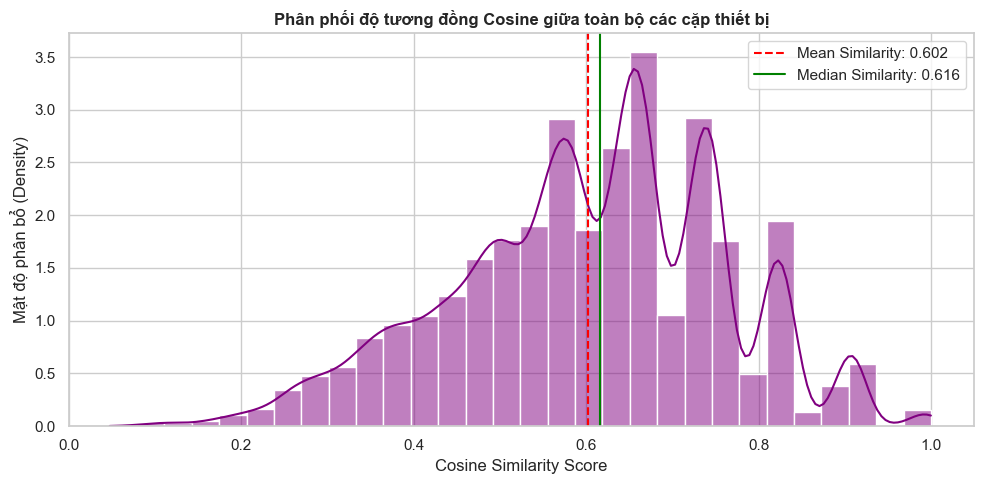

  ✅ ĐẠT KỲ VỌNG: Điểm Cosine trung bình nằm ở vùng trung tâm lý tưởng: 0.602
  ✅ ĐẠT TIÊU CHUẨN HÌNH HỌC: Không có hiện tượng dồn ứ dữ liệu ở vạch 1.0 (Không gian phân tách tốt).


In [21]:
validate_vector_discriminability(feature_matrix)